## **Apprendimento non supervisionato**


Nell’apprendimento **non supervisionato** a differenza dell'apprendimento supervisionato non conosciamo le risposte.

In altri termini abbiamo le varia variabili X ma non le Y.

L'idea di fondo è che un algoritmo **non supervisionato** deve scoprire da solo strutture, pattern o relazioni nascoste nei dati


**Esempi di apprendimento non supervisionato:**

In questa sezione inseriamo un elenco di possibili esempi di apprendimento non supervisionato.
Questo corso farà dei cenni solo sul clustering però è importante avere almeno una idea degli altri possibili ambiti di applicazione.

Ecco un elenco (non esaustivo)
- Raggruppare dati simili → **Clustering**
- Trovare rappresentazioni compatte → **Riduzione della dimensionalità** (come l'analisi delle componenti principali PCA, o altre tecniche più avanzate tipo  t-SNE e  UMAP…)
- Identificare associazioni frequenti → **Regole di associazione** (market basket analysis)
- Rilevare anomalie:  **Outlier detection**
- Modellare la distribuzione dei dati:  **Modelli di densità** (es. Gaussian Mixture Models)

## **Il Clustering: definizione e obiettivi**

Il concetto di cluster in realtà è qualcosa di ampio e non ne esiste una definizione precisa o univoca.

L'idea è quella di dividere i dati di un dataset in un insieme di gruppi (detti appunto cluster) in modo che gli oggetti all’interno di uno stesso cluster siano **più simili** tra loro rispetto agli oggetti appartenenti ad altri cluster.

Quello che è "da capire" è cosa si intenda per "più simili" e poi "quanti gruppi fare".


Nel clustering infatti non sappiamo a priori quanti né quali gruppi esistono. Non esiste una “risposta corretta” assoluta (a differenza della classificazione).
La qualità dipende dalla definizione di **similarità/distanza** e dall’algoritmo scelto

E' importante riflettere sul concetto di distanza e su quello di similarità (che non è esattamente una distanza).


**Esempi di applicazioni comuni del clustering**

Si inserisce qui un elenco di applicazione del clustering.
Anche questa lista non è esaustiva ma vuole nuovamente dare una idea della vastistà dei possibili utilizzi.

- Segmentazione clienti (marketing)
- Raggruppamento di documenti / notizie / recensioni simili
- Analisi di immagini (segmentazione, quantizzazione colori)
- Compressione dati
- Biologia (raggruppamento geni con espressione simile)
- Rilevamento di comunità nelle reti sociali
- Pre-elaborazione dati prima di algoritmi supervisionati


##  Tipologie principali di algoritmi di clustering

Veniamo quindi ad analizzare le varie tipologie di algoritmi di clustering.
Quello che conta, dopo aver capito l'idea di cluster e aver visto qualche esempio di algoritmo base, conoscere le diverse possibilità e valutare quale applicare.



| Tipo                      | Esempi principali                  | Numero di cluster da specificare? | Forma dei cluster          | Gestisce rumore/outlier? | Complessità approssimativa |
|---------------------------|------------------------------------|------------------------------------|----------------------------|---------------------------|-----------------------------|
| **Partizionale**          | K-Means, K-Medoids, Fuzzy C-Means  | Sì (k)                             | Sferici / convessi         | No (sensibile)            | O(n) – medio-bassa          |
| **Basato su densità**     | DBSCAN, , HDBSCAN            | No                                 | Qualsiasi                  | Sì (ottimo)               | O(n log n) – medio          |
| **Gerarchico**            | Agglomerativo, Divisivo            | No (si sceglie dopo)               | Qualsiasi                  | Dipende dal linkage       | O(n²) – alta                |
| **Basato su modelli**     | Gaussian Mixture Models (GMM)      | Sì                                 | Ellissoidali (probabilistico) | Sì (soft)              | Medio-alta                  |
| **Spettrale**             | Spectral Clustering                | Sì                                 | Non convessi               | Dipende                   | O(n³) – molto alta          |

### Breve confronto intuitivo

- **K-Means**
- Aspetti "pro": veloce, intuitivo, ma assume cluster sferici e simili per dimensione  
- "Contro": fallisce su forme complesse (lune, cerchi concentrici…)

- **DBSCAN**
- Aspetti "pro":  non richiede k, trova cluster di forma arbitraria, riconosce rumore  
- Contro: sensibile ai parametri

- **Clustering gerarchico**
-  produce dendrogramma: è un processo quindi utile per capire la struttura  
-  "Contro": computazionalmente costoso su dataset grandi

##  Come misuriamo la qualità di un clustering?

Poiché non abbiamo etichette vere, usiamo indici **interni** (basati solo sui dati e sui cluster trovati).

Ne esistono diversi e non li approfondiremo. Ne elenchiamo alcuni per completezza per per dare dei riferimenti da eventualmente ricercare:

- **Indice di Silhouette**: numero compreso fra da -1 a +1  
  (valori vicini a +1 = cluster ben separati e compatti)

- **Inertia / Within-Cluster Sum of Squares** (WSS): solo per K-Means  
  (più basso = meglio, ma diminuisce sempre con k crescente)

- **Metodo del gomito**:  cerchiamo il “gomito” nel grafico inertia vs k



CENNI: Se abbiamo etichette vere (valutazione didattica o semi-supervisionata):
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)


## Passi tipici di un'analisi di clustering

Qui di seguito inseriamo una "pipeline" orientativa ma non esclusiva.

1. **Pre-elaborazione** obbligatoria:
   - Gestione missing values
   - Standardizzazione / normalizzazione (molto importante!)
   - Eventuale riduzione della dimensionalità (PCA…)

2. **Scelta della metrica di distanza**  
   (Euclidea, Manhattan, Cosine, Jaccard…)
   A lezione si è parlato di differenza fra distanza e similarità. Si veda la voce di wikipedia (per esempio) per approfondire.

3. **Scelta dell’algoritmo** in base alla forma attesa dei cluster e alla presenza di rumore

4. **Scelta dei parametri** (k, eps, min_samples…)

5. **Esecuzione** e visualizzazione quando possibile/utile

6. **Valutazione** con più indici + interpretazione business/domain

7. **Iterazione** — il clustering è quasi sempre esplorativo



# **K-Means**

Il K-Means è basato sull'idea di trovare dei centri (detti centroidi) che caratterizzino i diversi clusters.


**Idea di fondo**  

Dividiamo i punti in **k gruppi** cercando di rendere ogni gruppo il più compatto possibile rispetto al suo "centro" (centroide).

IMPORTANTE: k deve essere indicato a priori.


**Come funziona in pratica (passaggi semplificati)**

1. Scegliamo **k** (numero di cluster che vogliamo ottenere)
2. Peschiamo a caso **k punti** e li usiamo come centroidi iniziali
3. Per ogni punto del dataset:  
   → calcoliamo la distanza da tutti i k centroidi  
   → lo assegniamo al centroide più vicino
4. Ricalcoliamo ogni centroide come **media** (baricentro) di tutti i punti che gli sono stati assegnati
5. Torniamo al punto 3 finché i centroidi si spostano pochissimo oppure dopo un numero massimo di iterazioni

**Caratteristiche importanti**

- Veloce
- Scalabile anche a dataset molto grandi
- Facile da capire e da spiegare

**Limiti principali**

- Devi decidere **k** prima di partire
- Molto sensibile alla posizione iniziale dei centroidi
- Funziona bene solo con cluster **tondeggianti** e di **dimensione simile**
- Soffre tantissimo con la presenza di **outlier**
- Non riesce a trovare cluster con forme strane (mezzelune, anelli, linee…)



In [ ]:
import random
import math
from collections import defaultdict

def distanza_euclidea(p1, p2):
    """Distanza euclidea tra due punti"""
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

def kmeans_manuale(dati, k, max_iter=100, tol=1e-4, seed=42):
    """
    Implementazione semplice di K-Means senza librerie
    Parametri:
        dati: lista di tuple/liste (punti)
        k: numero di cluster
        max_iter: massimo numero di iterazioni
        tol: tolleranza per fermare quando i centroidi si muovono poco
    """
    random.seed(seed)
    n = len(dati)
    dim = len(dati[0])

    # 1. Inizializzazione casuale dei centroidi
    indici = random.sample(range(n), k)
    centroidi = [dati[i] for i in indici]

    for iterazione in range(max_iter):
        # 2. Assegnazione: ogni punto va al centroide più vicino
        assegnazioni = defaultdict(list)
        for idx, punto in enumerate(dati):
            distanze = [distanza_euclidea(punto, c) for c in centroidi]
            cluster = distanze.index(min(distanze))
            assegnazioni[cluster].append(idx)

        # 3. Aggiornamento centroidi
        nuovi_centroidi = []
        for cluster in range(k):
            if not assegnazioni[cluster]:
                # Se un cluster è vuoto → riassegniamo un punto casuale
                nuovo_centro = dati[random.randint(0, n-1)]
            else:
                punti_cluster = [dati[i] for i in assegnazioni[cluster]]
                nuovo_centro = []
                for d in range(dim):
                    coord_media = sum(p[d] for p in punti_cluster) / len(punti_cluster)
                    nuovo_centro.append(coord_media)
            nuovi_centroidi.append(tuple(nuovo_centro))

        # 4. Controllo convergenza
        spostamento = max(
            distanza_euclidea(c_old, c_new)
            for c_old, c_new in zip(centroidi, nuovi_centroidi)
        )

        centroidi = nuovi_centroidi

        if spostamento < tol:
            print(f"Convergenza raggiunta dopo {iterazione+1} iterazioni")
            break

    # Prepariamo risultato
    labels = [-1] * n
    for cluster, indici in assegnazioni.items():
        for idx in indici:
            labels[idx] = cluster

    return labels, centroidi


# ────────────────────────────────────────────────
# Esempio di utilizzo
# ────────────────────────────────────────────────

# Dati di prova (2D)
punti = [
    (1, 2), (1.5, 1.8), (1.2, 2.1),
    (5, 8),  (5.5, 8.2), (4.8, 7.9),
    (9, 1),  (8.7, 1.3), (9.2, 0.8)
]

print("Esecuzione K-Means manuale...")
etichette, centroidi = kmeans_manuale(punti, k=3, max_iter=50, tol=0.0001)

print("\nEtichette:", etichette)
print("Centroidi finali:")
for i, c in enumerate(centroidi):
    print(f"Cluster {i}: {c}")



Esecuzione K-Means manuale...
Convergenza raggiunta dopo 3 iterazioni

Etichette: [1, 1, 1, 2, 2, 2, 0, 0, 0]
Centroidi finali:
Cluster 0: (8.966666666666667, 1.0333333333333332)
Cluster 1: (1.2333333333333334, 1.9666666666666668)
Cluster 2: (5.1000000000000005, 8.033333333333333)


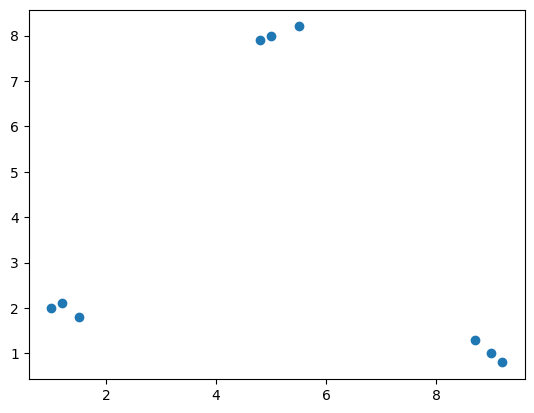

In [ ]:
import matplotlib.pyplot as plt

# Plot dei dati
punti = [
    (1, 2), (1.5, 1.8), (1.2, 2.1),
    (5, 8),  (5.5, 8.2), (4.8, 7.9),
    (9, 1),  (8.7, 1.3), (9.2, 0.8)
]

x= []
y= []
for i in punti:
  x.append(i[0])
  y.append(i[1])


plt.plot(x,y, 'o')





## **DBSCAN**

**Tipo di algoritmo**  

E' un algoritm basato sulla **densità**

**Idea di fondo**  

Un cluster è (almeno idealmente) una zona dove i punti sono molto vicini tra loro (alta densità), separata da zone dove i punti sono radi o assenti (bassa densità).

**Concetti fondamentali**

- **ε (eps)** = raggio massimo entro cui cerchiamo vicini  
- **MinPts** = numero minimo di punti (incluso sé stesso) che devono esserci entro ε per essere un **core point**

Tre tipi di punti:

1. **Core point** → ha almeno MinPts punti nel suo intorno di raggio ε  
2. **Border point** → non è core, ma si trova entro ε da almeno un core point  
3. **Noise / outlier** → non è core e non è raggiungibile da nessun core point

**Vantaggi principali**

- Non devi dire quanti cluster ci sono
- Riconosce cluster di forma qualsiasi
- Identifica automaticamente gli outlier

**Svantaggi principali**

- Sensibilissimo a ε e MinPts
- Soffre con densità molto diverse tra cluster

## Confronto finale

| Caratteristica              | K-Means                          | DBSCAN                              |
|-----------------------------|----------------------------------|-------------------------------------|
| Devi scegliere k?           | Sì                               | No                                  |
| Forma dei cluster           | Solo convessi / sferici          | Qualsiasi forma                     |
| Gestione outlier            | Molto sensibile                  | Li riconosce e li isola            |
| Parametri principali        | k                                | ε (raggio) + MinPts                 |
| Velocità                    | Molto veloce                     | Mediamente più lento                |


